# Model Comparison — Option A vs Option B, 4 algorithms

Compares 8 model variants on the held-out 2024-25 test season:
- Option A — predict next-season OVR directly
- Option B — predict 8 underlying stats, then apply the OVR formula
- 4 algorithms: XGBoost, MLP (sklearn neural net), Autoencoder + KNN, Ensemble (XGB+MLP avg)

Run `python3 scripts/train_models.py` first to generate `outputs/predictions/test_predictions.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

preds = pd.read_csv('../outputs/predictions/test_predictions.csv')
model_cols = [c for c in preds.columns if c.startswith(('optA_', 'optB_'))]
actual = preds['actual_ovr']
print(f'{len(preds):,} test rows, {len(model_cols)} models')
preds.head()

292 test rows, 8 models


,Player,Season,next_Season,Age,actual_ovr,optA_xgboost,optA_mlp,optA_autoencoder,optA_ensemble,optB_xgboost,optB_mlp,optB_autoencoder,optB_ensemble
0,Aaron Gordon,2023,2024.0,27.0,83.0,77.180305,69.260875,75.24,73.220590,76.825410,44.727432,78.740339,64.924537
1,Aaron Holiday,2023,2024.0,26.0,56.8,44.352230,41.512619,52.01,42.932425,33.062514,43.014040,42.342619,34.000035
2,Aaron Nesmith,2023,2024.0,23.0,69.5,44.419700,43.873515,53.76,44.146608,34.989962,51.724439,37.753500,34.279004
3,Aaron Wiggins,2023,2024.0,24.0,73.7,48.150726,45.523038,57.58,46.836882,38.940693,44.876736,49.769763,37.877607
4,Al Horford,2023,2024.0,36.0,74.1,55.718384,61.740017,67.62,58.729200,61.763364,37.923047,69.750445,49.729051


## 1. Metrics table

In [2]:
def metrics(actual_arr, pred_arr):
    err = pred_arr - actual_arr
    return pd.Series({
        'MAE':  np.mean(np.abs(err)),
        'RMSE': np.sqrt(np.mean(err ** 2)),
        'R^2':  1 - np.sum(err ** 2) / np.sum((actual_arr - actual_arr.mean()) ** 2),
    })

metrics_df = pd.DataFrame({m: metrics(actual, preds[m]) for m in model_cols}).T
metrics_df.index.name = 'model'
metrics_df.sort_values('MAE').round(3)

,MAE,RMSE,R^2
model,,,
optA_ensemble,10.147,12.869,0.528
optA_mlp,10.348,13.223,0.502
optA_xgboost,10.554,13.155,0.507
optA_autoencoder,11.111,13.645,0.469
optB_xgboost,11.490,14.662,0.387
optB_autoencoder,12.148,15.122,0.348
optB_ensemble,13.863,16.675,0.207
optB_mlp,19.746,23.798,-0.615


## 2. MAE bar chart

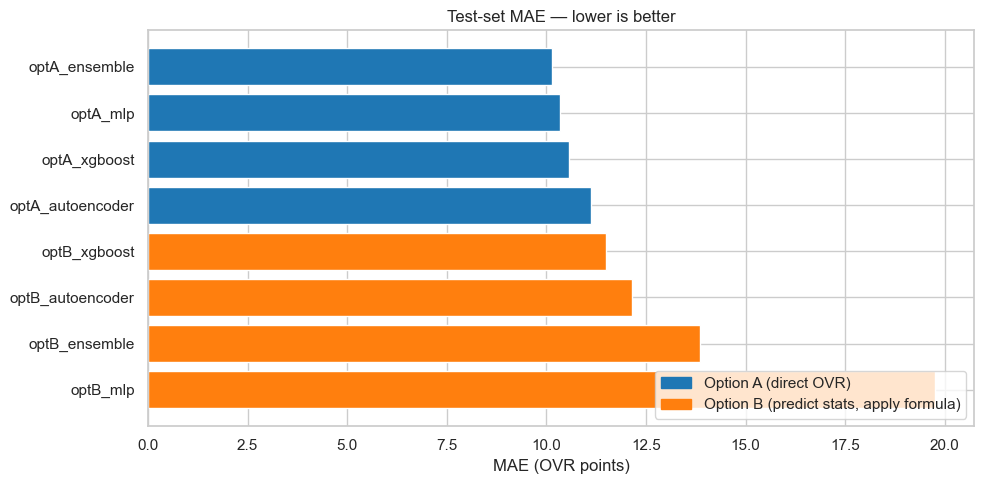

In [3]:
order = metrics_df['MAE'].sort_values().index
colors = ['#1f77b4' if m.startswith('optA_') else '#ff7f0e' for m in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(order, metrics_df.loc[order, 'MAE'], color=colors)
ax.set_xlabel('MAE (OVR points)')
ax.set_title('Test-set MAE — lower is better')
ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#1f77b4', label='Option A (direct OVR)'),
                   Patch(color='#ff7f0e', label='Option B (predict stats, apply formula)')], loc='lower right')
plt.tight_layout()
plt.show()

## 3. Predicted vs Actual scatter

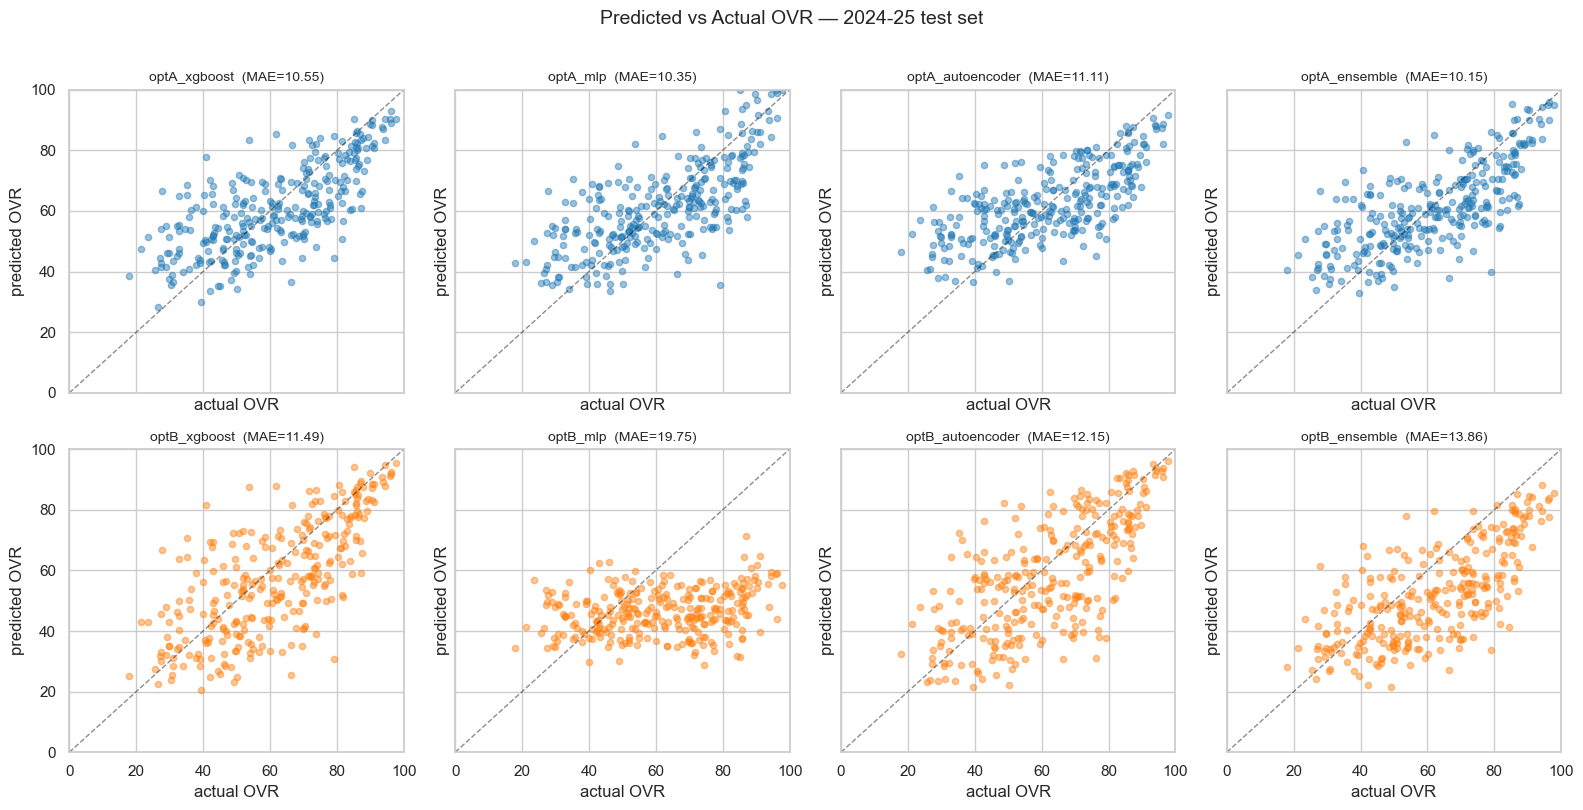

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for ax, m in zip(axes.flat, model_cols):
    color = '#1f77b4' if m.startswith('optA_') else '#ff7f0e'
    ax.scatter(actual, preds[m], alpha=0.45, s=20, color=color)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, lw=1)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_title(f"{m}  (MAE={metrics_df.loc[m, 'MAE']:.2f})", fontsize=10)
    ax.set_xlabel('actual OVR')
    ax.set_ylabel('predicted OVR')
fig.suptitle('Predicted vs Actual OVR — 2024-25 test set', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Residuals (predicted − actual) by actual OVR

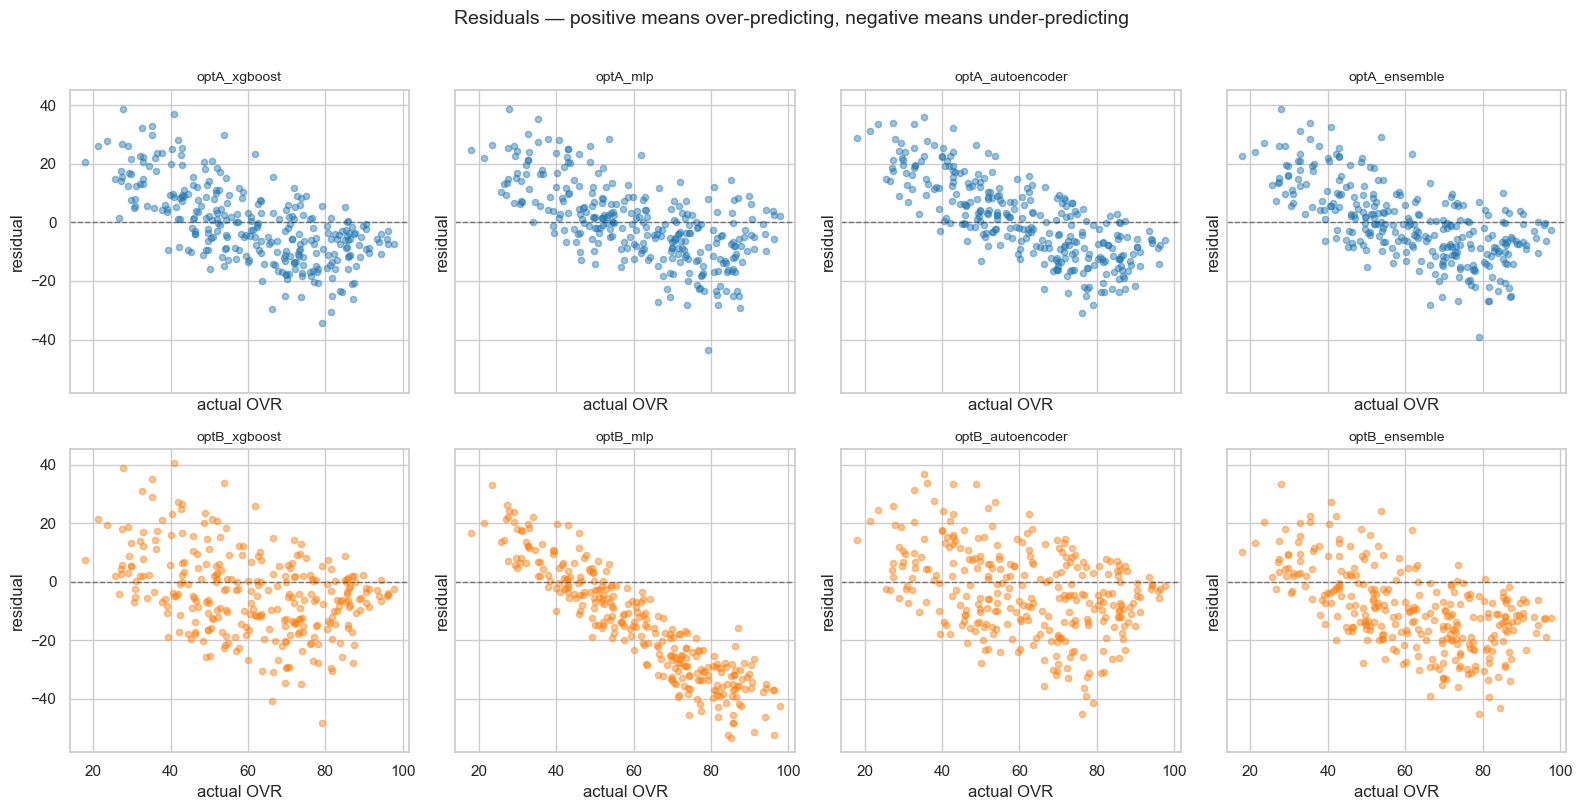

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for ax, m in zip(axes.flat, model_cols):
    color = '#1f77b4' if m.startswith('optA_') else '#ff7f0e'
    resid = preds[m] - actual
    ax.scatter(actual, resid, alpha=0.45, s=20, color=color)
    ax.axhline(0, color='k', linestyle='--', alpha=0.5, lw=1)
    ax.set_title(m, fontsize=10)
    ax.set_xlabel('actual OVR'); ax.set_ylabel('residual')
fig.suptitle('Residuals — positive means over-predicting, negative means under-predicting', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Top-10 agreement

How many of each model's top-10 predicted players overlap with the actual top-10?

In [6]:
actual_top10 = set(preds.nlargest(10, 'actual_ovr')['Player'])
rows = []
for m in model_cols:
    pred_top10 = set(preds.nlargest(10, m)['Player'])
    rows.append({'model': m, 'overlap_with_actual_top10': len(actual_top10 & pred_top10)})

overlap_df = pd.DataFrame(rows).sort_values('overlap_with_actual_top10', ascending=False).reset_index(drop=True)
overlap_df

,model,overlap_with_actual_top10
0,optA_autoencoder,7
1,optB_xgboost,7
2,optB_autoencoder,7
3,optA_xgboost,6
4,optA_mlp,5
5,optA_ensemble,5
6,optB_ensemble,5
7,optB_mlp,2


## 6. Per-player example: notable players' predicted vs actual

In [7]:
notable = [
    'LeBron James', 'Nikola Jokić', 'Tyrese Haliburton', 'Anthony Edwards',
    'Luka Dončić', 'Jayson Tatum', 'Shai Gilgeous-Alexander', 'Stephen Curry',
]
sub = preds[preds['Player'].isin(notable)].copy()
show_cols = ['Player', 'Age', 'actual_ovr'] + model_cols
sub[show_cols].round(1).set_index('Player')

,Age,actual_ovr,optA_xgboost,optA_mlp,optA_autoencoder,optA_ensemble,optB_xgboost,optB_mlp,optB_autoencoder,optB_ensemble
Player,,,,,,,,,,
Anthony Edwards,21.0,88.6,80.9,83.8,75.6,82.4,82.8,60.7,80.1,77.3
Jayson Tatum,24.0,93.4,87.8,92.9,90.6,90.3,90.7,55.6,95.0,81.3
LeBron James,38.0,88.9,77.0,86.4,74.4,81.7,79.4,52.5,77.9,75.4
Luka Dončić,23.0,94.3,90.3,98.6,88.2,94.5,94.9,59.5,92.8,88.1
Nikola Jokić,27.0,97.7,90.2,100.0,91.6,95.1,95.4,55.2,96.1,85.4
Shai Gilgeous-Alexander,24.0,96.2,93.1,98.9,82.0,96.0,91.7,59.2,90.7,83.8
Stephen Curry,34.0,89.3,84.4,79.6,78.5,82.0,83.7,56.7,81.9,78.0
Tyrese Haliburton,22.0,90.4,89.9,96.8,84.7,93.3,88.3,61.8,90.0,84.5


## 7. Notable-player visual: each model's prediction vs actual

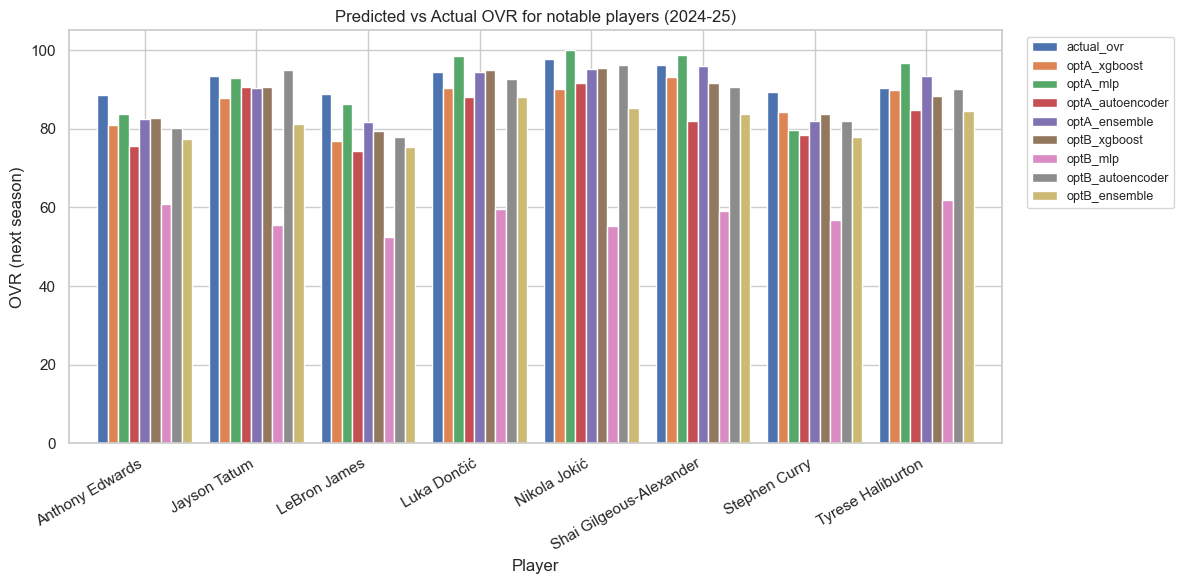

In [8]:
if len(sub) > 0:
    plot_df = sub.set_index('Player')[['actual_ovr'] + model_cols]
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_df.plot(kind='bar', ax=ax, width=0.85)
    ax.set_ylabel('OVR (next season)')
    ax.set_title('Predicted vs Actual OVR for notable players (2024-25)')
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('None of the listed notable players appeared in the test set (check accents and spelling).')

## 8. Verdict

Read off the metrics table at the top:

- Best overall: the row with the lowest MAE.
- Option A vs Option B: the comparison shows whether direct prediction or stat-then-formula wins. Usually direct is easier; stat-then-formula compounds 8 model errors.
- Deep learning vs trees: if XGBoost beats MLP / Autoencoder, the dataset is too small for deep learning to shine. That is a real result, not a failure.
- Ensemble lift: if `ensemble` MAE < min(`xgb`, `mlp`), the ensemble adds value; if not, it is averaging in a weaker model.